In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

df = pd.read_csv('FIFA-21 Complete.csv', sep=';', encoding='utf-8')
df.head()


,player_id,name,nationality,position,overall,age,hits,potential,team
0,158023,Lionel Messi,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona
1,20801,Cristiano Ronaldo,Portugal,ST|LW,93,35,276,93,Juventus
2,190871,Neymar Jr,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain
3,203376,Virgil van Dijk,Netherlands,CB,91,29,127,92,Liverpool
4,200389,Jan Oblak,Slovenia,GK,91,27,47,93,Atlético Madrid


In [5]:
df['high_potential'] = (df['potential'] >= 80).astype(int)
y = df['high_potential']

y.value_counts()


high_potential
0    16070
1     1911
Name: count, dtype: int64

Класс 0 (Низкий потенциал, <80):  16070 (89.37%)
Класс 1 (Высокий потенциал, >=80): 1911 (10.63%)
Соотношение 0/1: 8.41:1


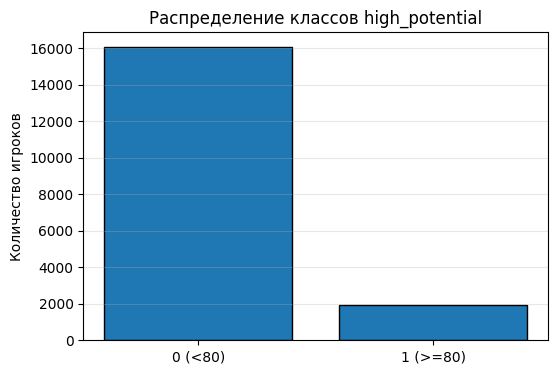

In [7]:
#БАЛАНС
counts = y.value_counts()
share = y.value_counts(normalize=True) * 100

print(f"Класс 0 (Низкий потенциал, <80):  {counts.get(0,0)} ({share.get(0,0):.2f}%)")
print(f"Класс 1 (Высокий потенциал, >=80): {counts.get(1,0)} ({share.get(1,0):.2f}%)")
print(f"Соотношение 0/1: {counts[0]/counts[1]:.2f}:1")

plt.figure(figsize=(6,4))
plt.bar(['0 (<80)', '1 (>=80)'], counts.values, edgecolor='black')
plt.title('Распределение классов high_potential')
plt.ylabel('Количество игроков')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [19]:
# 2. ОЦЕНКА АЛГОРИТМОВ КЛАССИФИКАЦИИ

X = df[['overall', 'age']].copy()
if 'position' in df.columns:
    df['main_position'] = df['position'].astype(str).str.split('|').str[0]
    position_dummies = pd.get_dummies(df['main_position'], prefix='pos', drop_first=True)
    X = pd.concat([X, position_dummies], axis=1)

y = df['high_potential']
X = X.fillna(X.median())

print(f"Признаки: {X.shape[1]}, Примеры: {X.shape[0]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nОбучение kNN")
knn = KNeighborsClassifier()
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
print(f"Лучшие параметры kNN: {knn_grid.best_params_}, F1: {knn_grid.best_score_:.4f}")

print("\nОбучение Decision Tree")
tree = DecisionTreeClassifier(random_state=42)
tree_param_grid = {'max_depth': [3, 5, 7, 9, None], 'criterion': ['gini', 'entropy']}
tree_grid = GridSearchCV(tree, tree_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_
print(f"Лучшие параметры Tree: {tree_grid.best_params_}, F1: {tree_grid.best_score_:.4f}")


Признаки: 16, Примеры: 17981

Обучение kNN
Лучшие параметры kNN: {'n_neighbors': 3, 'weights': 'uniform'}, F1: 0.7662

Обучение Decision Tree
Лучшие параметры Tree: {'criterion': 'entropy', 'max_depth': 7}, F1: 0.8043



Метрики на тестовой выборке:
  Метрика      kNN  Decision Tree
 Accuracy 0.953475       0.959778
Precision 0.823293       0.828413
   Recall 0.715532       0.783595
 F1-score 0.765640       0.805381
  ROC-AUC 0.921803       0.985219

Baseline (всегда 0): 0.8938


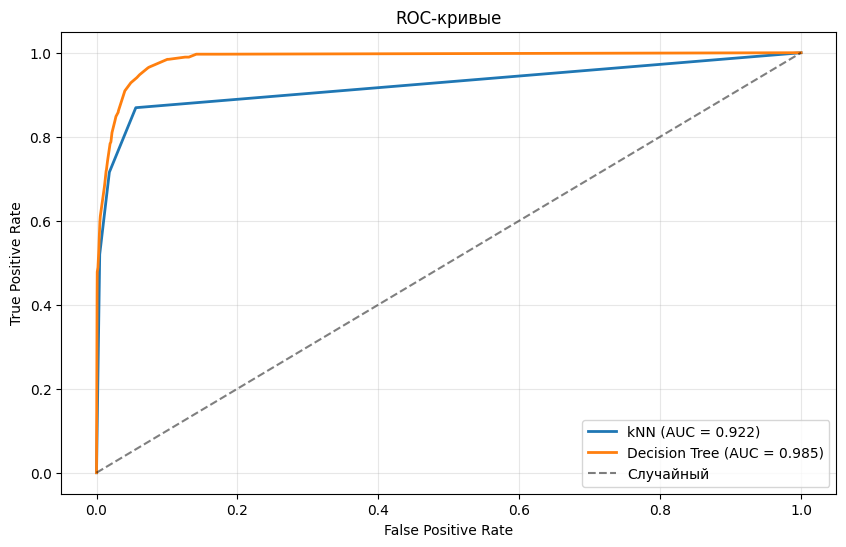

In [18]:
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ


def evaluate_model(model, X_test, y_test, scaled=False):
    if scaled:
        X_test_processed = scaler.transform(X_test)
    else:
        X_test_processed = X_test
    
    y_pred = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }, y_pred_proba, confusion_matrix(y_test, y_pred)


print("\nМетрики на тестовой выборке:")

knn_metrics, knn_proba, cm_knn = evaluate_model(best_knn, X_test, y_test, scaled=True)
tree_metrics, tree_proba, cm_tree = evaluate_model(best_tree, X_test, y_test, scaled=False)

# Таблица сравнения
results = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'kNN': [knn_metrics[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']],
    'Decision Tree': [tree_metrics[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']]
})
print(results.to_string(index=False))

baseline_acc = 1 - y_test.mean()
print(f"\nBaseline (всегда 0): {baseline_acc:.4f}")

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_knn, tpr_knn, label=f'kNN (AUC = {knn_metrics["ROC-AUC"]:.3f})', linewidth=2)
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {tree_metrics["ROC-AUC"]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()
